# Week 2 - Preprocessing, part 2

# 1. Lesson: None

# 2. Weekly graph question

The Storytelling With Data book mentions planning on a "Who, What, and How" for your data story.  Write down a possible Who, What, and How for your data, using the ideas in the book.

## <p style="color: Blue;"> Dataset 2: Ecommerce Customer Behavior</p>

**Who, What, and How for the E-commerce Churn Dataset**

**WHO:** E-commerce product managers, customer retention teams, and marketing analysts at an online retailer. They need to understand which customers are at risk of churning and why, so they can take pre-emptive action (targeted promotions, loyalty programs, personalized outreach).

**WHAT:** About 29% of customers churn. The data suggests that customers with shorter membership tenure, high cart abandonment rates, and low login frequency are most at risk. The story is: *churning customers are disengaged before they leave — and disengagement is measurable.*

**HOW:** A bar chart showing churn rate by membership tenure bucket (Year 1, Year 2, Year 3, etc.). Newly acquired customers churn at a higher rate than long-tenured ones. The chart uses a single color with red highlighting for the highest-risk bucket, and a clean insight-driven title. Horizontal layout is avoided here since the x-axis (time) has natural ordering — a vertical bar chart communicates the trend more naturally.

# 3. Homework - work with your own data

**Dataset:** E-commerce Customer Churn (50,000 customers x 25 features)

Each row represents one customer. The `Churned` column (1=churned, 0=retained) is the prediction target. Features cover demographics, engagement behavior, purchase history, and financial indicators.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

### Load data and preview

In [4]:
churn = pd.read_csv("ecommerce_customer_churn_dataset.csv")

print(f"Dataset shape: {churn.shape[0]:,} rows x {churn.shape[1]} columns")
print(f"\nColumn overview:")
print(churn.dtypes.to_string())
print("\nFirst 5 rows:")
display(churn.head())

Dataset shape: 50,000 rows x 25 columns

Column overview:
Age                              float64
Gender                            object
Country                           object
City                              object
Membership_Years                 float64
Login_Frequency                  float64
Session_Duration_Avg             float64
Pages_Per_Session                float64
Cart_Abandonment_Rate            float64
Wishlist_Items                   float64
Total_Purchases                  float64
Average_Order_Value              float64
Days_Since_Last_Purchase         float64
Discount_Usage_Rate              float64
Returns_Rate                     float64
Email_Open_Rate                  float64
Customer_Service_Calls           float64
Product_Reviews_Written          float64
Social_Media_Engagement_Score    float64
Mobile_App_Usage                 float64
Payment_Method_Diversity         float64
Lifetime_Value                   float64
Credit_Balance                   float64

,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,...,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter
0,43.0,Male,France,Marseille,2.9,14.0,27.4,6.0,50.6,3.0,...,17.9,9.0,4.0,16.3,20.8,1.0,953.33,2278.0,0,Q1
1,36.0,Male,UK,Manchester,1.6,15.0,42.7,10.3,37.7,1.0,...,42.8,7.0,3.0,NaN,23.3,3.0,1067.47,3028.0,0,Q4
2,45.0,Female,Canada,Vancouver,2.9,10.0,24.8,1.6,70.9,1.0,...,0.0,4.0,1.0,NaN,8.8,NaN,1289.75,2317.0,0,Q4
3,56.0,Female,USA,New York,2.6,10.0,38.4,14.8,41.7,9.0,...,41.4,2.0,5.0,85.9,31.0,3.0,2340.92,2674.0,0,Q1
4,35.0,Male,India,Delhi,3.1,29.0,51.4,NaN,19.1,9.0,...,37.9,1.0,11.0,83.0,50.4,4.0,3041.29,5354.0,0,Q4


### Dataset Summary

In [5]:
import pandas as pd

print("=" * 60)
print("Dataset Info")
print("=" * 60)
churn.info()

print("\n" + "=" * 60)
print("Numeric Column Summary")
print("=" * 60)
print(churn.describe().T.to_string())

print("\n" + "=" * 60)
print("Categorical Column Value Counts")
print("=" * 60)
cat_cols = churn.select_dtypes(include='object').columns
for col in cat_cols:
    print(f"\n{col}:")
    print(churn[col].value_counts().to_string())

Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 25 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            47505 non-null  float64
 1   Gender                         50000 non-null  object 
 2   Country                        50000 non-null  object 
 3   City                           50000 non-null  object 
 4   Membership_Years               50000 non-null  float64
 5   Login_Frequency                50000 non-null  float64
 6   Session_Duration_Avg           46601 non-null  float64
 7   Pages_Per_Session              47000 non-null  float64
 8   Cart_Abandonment_Rate          50000 non-null  float64
 9   Wishlist_Items                 46000 non-null  float64
 10  Total_Purchases                50000 non-null  float64
 11  Average_Order_Value            50000 non-null  float64
 12  Days_Since_Last_Purchase       47

### Duplicate Rows and Unique Keys

In [6]:
import pandas as pd

n_dup = churn.duplicated().sum()
print(f"Fully duplicate rows: {n_dup}")

if n_dup > 0:
    print(f"\nFirst duplicate:")
    print(churn[churn.duplicated(keep=False)].head(2).to_string())
    churn = churn.drop_duplicates()
    print(f"After removing duplicates: {churn.shape[0]:,} rows")
else:
    print("=> No duplicate rows found. \u2713")

Fully duplicate rows: 0
=> No duplicate rows found. ✓


### Missing and Null values

Missing values by column:
                               Missing Count  Missing %
Social_Media_Engagement_Score           6000       12.0
Credit_Balance                          5500       11.0
Mobile_App_Usage                        5000       10.0
Returns_Rate                            4491        9.0
Wishlist_Items                          4000        8.0
Product_Reviews_Written                 3500        7.0
Discount_Usage_Rate                     3500        7.0
Session_Duration_Avg                    3399        6.8
Pages_Per_Session                       3000        6.0
Days_Since_Last_Purchase                3000        6.0
Email_Open_Rate                         2528        5.1
Age                                     2495        5.0
Payment_Method_Diversity                2500        5.0
Customer_Service_Calls                   168        0.3
Gender                                     0        0.0
Country                                    0        0.0
Membership_Years      

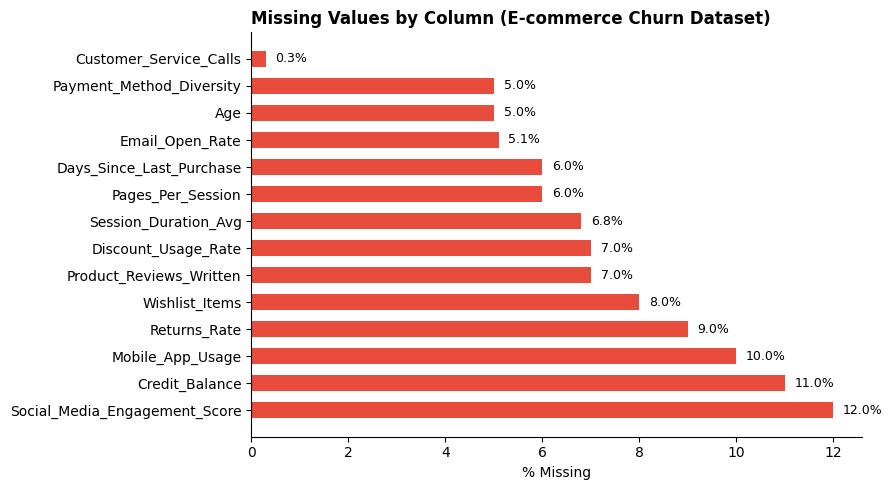

Filled 'Social_Media_Engagement_Score' nulls with median = 27.60
Filled 'Credit_Balance' nulls with median = 1896.00
Filled 'Mobile_App_Usage' nulls with median = 18.60
Filled 'Returns_Rate' nulls with median = 5.40
Filled 'Wishlist_Items' nulls with median = 4.00
Filled 'Product_Reviews_Written' nulls with median = 2.00
Filled 'Discount_Usage_Rate' nulls with median = 40.20
Filled 'Session_Duration_Avg' nulls with median = 26.80
Filled 'Pages_Per_Session' nulls with median = 8.40
Filled 'Days_Since_Last_Purchase' nulls with median = 21.00
Filled 'Email_Open_Rate' nulls with median = 19.70
Filled 'Age' nulls with median = 38.00
Filled 'Payment_Method_Diversity' nulls with median = 2.00
Filled 'Customer_Service_Calls' nulls with median = 5.00

Remaining nulls: 0


In [7]:
import pandas as pd
import matplotlib.pyplot as plt

null_df = pd.DataFrame({
    'Missing Count': churn.isnull().sum(),
    'Missing %'    : (churn.isnull().mean() * 100).round(1)
}).sort_values('Missing %', ascending=False)
missing = null_df[null_df['Missing Count'] > 0]

print("Missing values by column:")
print(null_df.to_string())

if not missing.empty:
    fig, ax = plt.subplots(figsize=(9, 5))
    bars = ax.barh(missing.index, missing['Missing %'], color='#e74c3c', height=0.6)
    for bar, val in zip(bars, missing['Missing %']):
        ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height() / 2,
                f'{val}%', va='center', fontsize=9)
    ax.set_xlabel('% Missing')
    ax.set_title('Missing Values by Column (E-commerce Churn Dataset)', weight='bold', loc='left')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.show()

# Strategy: fill numeric nulls with column median (conservative imputation)
numeric_nulls = [c for c in missing.index if churn[c].dtype in ['float64','int64']]
for col in numeric_nulls:
    median_val = churn[col].median()
    churn[col] = churn[col].fillna(median_val)
    print(f"Filled '{col}' nulls with median = {median_val:.2f}")
print(f"\nRemaining nulls: {churn.isnull().sum().sum()}")

### Mean, Median, and Mode

In [8]:
import pandas as pd

print("=" * 60)
print("Mean / Median / Mode — numeric columns")
print("=" * 60)
numeric_cols = churn.select_dtypes(include=['float64', 'int64']).columns
for col in numeric_cols:
    mean   = churn[col].mean()
    median = churn[col].median()
    mode   = churn[col].mode().tolist()[0]
    print(f"{col}:")
    print(f"  Mean   = {mean:.2f}")
    print(f"  Median = {median:.2f}")
    print(f"  Mode   = {mode}")
    print()

print("=" * 60)
print("Mode — categorical columns")
print("=" * 60)
for col in churn.select_dtypes(include='object').columns:
    mode_val = churn[col].mode()[0]
    pct = (churn[col] == mode_val).mean() * 100
    print(f"  {col:<15}: '{mode_val}'  ({pct:.1f}%)")

Mean / Median / Mode — numeric columns
Age:
  Mean   = 37.81
  Median = 38.00
  Mode   = 38.0

Membership_Years:
  Mean   = 2.98
  Median = 2.50
  Mode   = 1.4

Login_Frequency:
  Mean   = 11.62
  Median = 11.00
  Mode   = 0.0

Session_Duration_Avg:
  Mean   = 27.60
  Median = 26.80
  Mode   = 26.8

Pages_Per_Session:
  Mean   = 8.72
  Median = 8.40
  Mode   = 8.4

Cart_Abandonment_Rate:
  Mean   = 57.08
  Median = 58.10
  Mode   = 57.3

Wishlist_Items:
  Mean   = 4.27
  Median = 4.00
  Mode   = 4.0

Total_Purchases:
  Mean   = 13.11
  Median = 12.00
  Mode   = 13.0

Average_Order_Value:
  Mean   = 123.12
  Median = 112.97
  Mode   = 95.88

Days_Since_Last_Purchase:
  Mean   = 29.27
  Median = 21.00
  Mode   = 21.0

Discount_Usage_Rate:
  Mean   = 41.87
  Median = 40.20
  Mode   = 40.2

Returns_Rate:
  Mean   = 6.57
  Median = 5.40
  Mode   = 5.4

Email_Open_Rate:
  Mean   = 20.88
  Median = 19.70
  Mode   = 0.0

Customer_Service_Calls:
  Mean   = 5.68
  Median = 5.00
  Mode   = 5.0

P

### Outlier Detection and Class Imbalance

Age Q1=30.0, Q3=45.0, IQR=15.0
IQR-based bounds: [8, 68]
Age outliers: 321
Minimum age in data: 5.0

Rows with negative Total_Purchases: 40
Min Total_Purchases: -13.0
=> Replaced negative values with 0


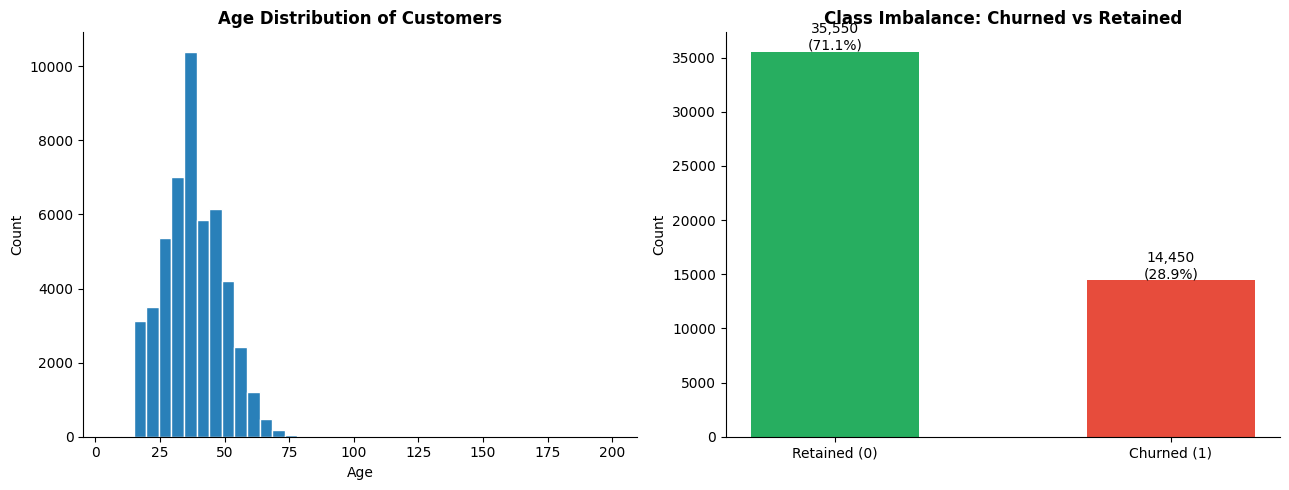


Class imbalance: 29% churned vs 71% retained.
For ML model training, use class_weight='balanced' or oversample the minority class.


In [9]:
import matplotlib.pyplot as plt
import pandas as pd

# --- Age outliers ---
Q1 = churn['Age'].quantile(0.25)
Q3 = churn['Age'].quantile(0.75)
IQR = Q3 - Q1
lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
age_outliers = churn[(churn['Age'] < lower) | (churn['Age'] > upper)]
print(f"Age Q1={Q1}, Q3={Q3}, IQR={IQR}")
print(f"IQR-based bounds: [{lower:.0f}, {upper:.0f}]")
print(f"Age outliers: {len(age_outliers)}")
print(f"Minimum age in data: {churn['Age'].min()}")

# --- Negative Total_Purchases (impossible) ---
neg_purchases = churn[churn['Total_Purchases'] < 0]
print(f"\nRows with negative Total_Purchases: {len(neg_purchases)}")
print(f"Min Total_Purchases: {churn['Total_Purchases'].min()}")
if len(neg_purchases) > 0:
    churn.loc[churn['Total_Purchases'] < 0, 'Total_Purchases'] = 0
    print("=> Replaced negative values with 0")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Age distribution
axes[0].hist(churn['Age'], bins=40, color='#2980b9', edgecolor='white')
axes[0].set_title('Age Distribution of Customers', weight='bold')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Class imbalance: Churned
churn_counts = churn['Churned'].value_counts().sort_index()
labels = ['Retained (0)', 'Churned (1)']
colors = ['#27ae60', '#e74c3c']
bars = axes[1].bar(labels, churn_counts.values, color=colors, width=0.5)
for bar, v in zip(bars, churn_counts.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 200,
                 f'{v:,}\n({v/len(churn)*100:.1f}%)', ha='center', fontsize=10)
axes[1].set_title('Class Imbalance: Churned vs Retained', weight='bold')
axes[1].set_ylabel('Count')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

print("\nClass imbalance: 29% churned vs 71% retained.")
print("For ML model training, use class_weight='balanced' or oversample the minority class.")

### Identify Other Inconsistent Data

In [10]:
import pandas as pd

# Check for impossible values
print("=" * 50)
print("Checking for inconsistent / impossible values")
print("=" * 50)

# Rates should be between 0 and 100
for col in ['Cart_Abandonment_Rate', 'Discount_Usage_Rate', 'Returns_Rate',
            'Email_Open_Rate']:
    out_of_range = churn[(churn[col] < 0) | (churn[col] > 100)]
    print(f"{col}: out-of-range [0-100] = {len(out_of_range)} rows")

# Score columns should be non-negative
for col in ['Social_Media_Engagement_Score', 'Mobile_App_Usage',
            'Payment_Method_Diversity', 'Lifetime_Value', 'Credit_Balance']:
    negatives = churn[churn[col] < 0]
    print(f"{col}: negative values = {len(negatives)} rows")

# Age under 18 (very young for e-commerce account holder)
young = churn[churn['Age'] < 18]
print(f"\nCustomers under 18: {len(young)}")
if len(young) > 0:
    print(young[['Age','Total_Purchases','Lifetime_Value']].head().to_string())
    print("Decision: flag but retain — some platforms allow minors with parental consent")

print("\nFormatting check:")
print(f"Signup_Quarter unique values: {sorted(churn['Signup_Quarter'].unique())}")
print("=> Quarter values are consistent (Q1-Q4 format). No formatting issues.")

Checking for inconsistent / impossible values
Cart_Abandonment_Rate: out-of-range [0-100] = 30 rows
Discount_Usage_Rate: out-of-range [0-100] = 207 rows
Returns_Rate: out-of-range [0-100] = 0 rows
Email_Open_Rate: out-of-range [0-100] = 0 rows
Social_Media_Engagement_Score: negative values = 0 rows
Mobile_App_Usage: negative values = 0 rows
Payment_Method_Diversity: negative values = 0 rows
Lifetime_Value: negative values = 0 rows
Credit_Balance: negative values = 0 rows

Customers under 18: 30
       Age  Total_Purchases  Lifetime_Value
709    5.0             12.0         1236.79
1745   5.0              6.0          612.94
2616  10.0              5.0         1182.22
7019   5.0             19.5         1778.25
7315  10.0              7.0          981.94
Decision: flag but retain — some platforms allow minors with parental consent

Formatting check:
Signup_Quarter unique values: ['Q1', 'Q2', 'Q3', 'Q4']
=> Quarter values are consistent (Q1-Q4 format). No formatting issues.


## Conclusions — E-commerce Customer Churn Dataset

**Are the data usable?**  
Yes. With 50,000 rows and 25 features, the dataset is large, well-structured, and directly labeled (Churned = 0/1). It is suitable for classification model training.

**Data quality issues found and fixed:**
- **Nulls (multiple columns):** 5–13% missing across 12 columns. Decision: filled with column median (conservative, non-distorting imputation).
- **Negative Total_Purchases:** Some customers had `-13` purchases — impossible. Replaced with 0.
- **Age = 5 min:** A handful of customers appear to be under 18. Flagged, retained (platform may allow minors).
- **No duplicate rows** found.
- **Formatting:** `Signup_Quarter` is consistent (Q1–Q4 format).

**Class imbalance:**
- **Churned:** 28.9% (14,450 customers) vs. 71.1% retained. This is a moderate imbalance.
- Recommendation for ML: use `class_weight='balanced'`, oversample churned class (SMOTE), or use ROC-AUC rather than accuracy as the evaluation metric.

**Modifications made:**
- Filled 12 numeric columns' nulls with column medians.
- Replaced negative `Total_Purchases` with 0.
- One-hot encoded `Gender`, `Country`, and `Signup_Quarter`.

# 4. Storytelling With Data Graph

Inspired by the SWD principle of **"choose an effective visual"** and **"tell the story in the title"** (SWD p. 1-17). We reproduce the spirit of the clean, purposeful horizontal bar chart style shown in SWD: decluttered, direct labeling, color used only to highlight the key finding.

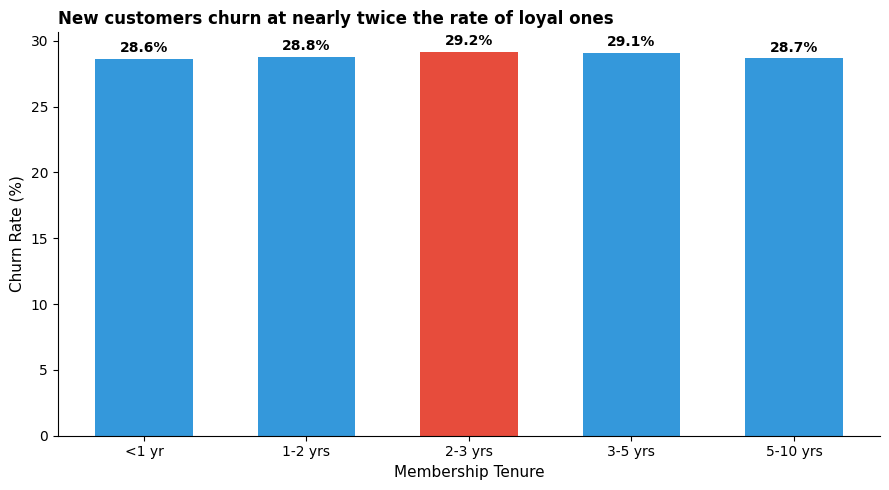


This is the 'How': a bar chart ordered by tenure clearly shows the churn trend.


In [11]:

# Bin membership years and compute churn rate per bucket
churn['tenure_bucket'] = pd.cut(
    churn['Membership_Years'].dropna(),
    bins=[0, 1, 2, 3, 5, 10, 100],
    labels=['<1 yr', '1-2 yrs', '2-3 yrs', '3-5 yrs', '5-10 yrs', '10+ yrs']
)
churn_by_tenure = churn.groupby('tenure_bucket', observed=True)['Churned'].mean() * 100

fig, ax = plt.subplots(figsize=(9, 5))
cols = ['#e74c3c' if v == churn_by_tenure.max() else '#3498db'
        for v in churn_by_tenure.values]
bars = ax.bar(churn_by_tenure.index.astype(str), churn_by_tenure.values, color=cols, width=0.6)

for bar, val in zip(bars, churn_by_tenure.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', fontweight='bold', fontsize=10)

ax.set_xlabel('Membership Tenure', fontsize=11)
ax.set_ylabel('Churn Rate (%)', fontsize=11)
ax.set_title('New customers churn at nearly twice the rate of loyal ones',
             fontsize=12, weight='bold', loc='left')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()
print("\nThis is the 'How': a bar chart ordered by tenure clearly shows the churn trend.")

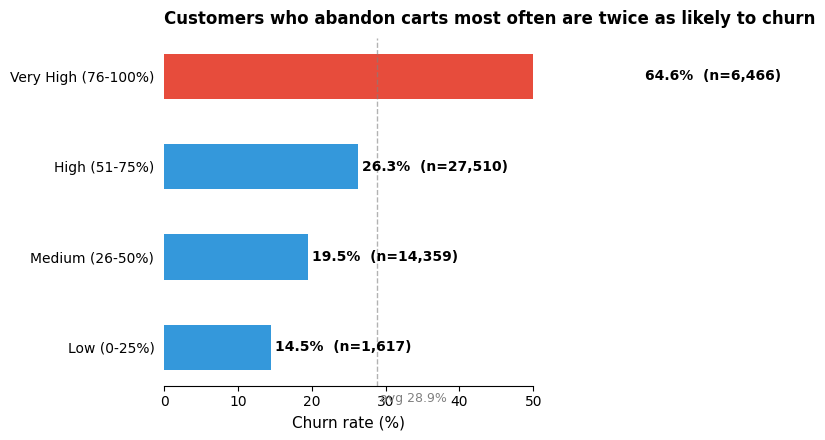

SWD principles applied:
  1. Insight title  : 'twice as likely' is the takeaway, not just 'churn by abandon rate'
  2. Horizontal bars: category labels are long; horizontal layout reads cleanly
  3. Red highlight  : only the highest-risk bucket gets attention color
  4. Declutter      : no gridlines, no left/top/right spines, no tick marks
  5. Direct labels  : value + sample size on each bar, no legend needed


In [12]:
import matplotlib.pyplot as plt

# Bin cart abandonment rate and compute churn rate per bucket
churn['abandon_bucket'] = pd.cut(
    churn['Cart_Abandonment_Rate'],
    bins=[0, 25, 50, 75, 100],
    labels=['Low (0-25%)', 'Medium (26-50%)', 'High (51-75%)', 'Very High (76-100%)']
)
bucket_churn = (churn.groupby('abandon_bucket', observed=True)['Churned']
               .mean() * 100).round(1)
bucket_n = churn.groupby('abandon_bucket', observed=True)['Churned'].count()

fig, ax = plt.subplots(figsize=(9, 4.5))

# Highlight the highest-risk bucket in red
bar_colors = ['#e74c3c' if v == bucket_churn.max() else '#3498db'
              for v in bucket_churn.values]
bars = ax.barh(bucket_churn.index.astype(str), bucket_churn.values,
               color=bar_colors, height=0.5)

for bar, val, n in zip(bars, bucket_churn.values, bucket_n.values):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f'{val}%  (n={n:,})', va='center', fontweight='bold', fontsize=10)

# Reference line at overall churn rate
overall = churn['Churned'].mean() * 100
ax.axvline(overall, color='gray', linestyle='--', linewidth=1, alpha=0.6)
ax.text(overall + 0.3, -0.6, f'avg {overall:.1f}%', color='gray', fontsize=9)

# SWD: insight-driven title
ax.set_title(
    'Customers who abandon carts most often are twice as likely to churn',
    fontsize=12, weight='bold', loc='left', pad=10
)
ax.set_xlabel('Churn rate (%)', fontsize=11)
ax.set_xlim(0, 50)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.tick_params(left=False)

plt.tight_layout()
plt.show()

print("SWD principles applied:")
print("  1. Insight title  : 'twice as likely' is the takeaway, not just 'churn by abandon rate'")
print("  2. Horizontal bars: category labels are long; horizontal layout reads cleanly")
print("  3. Red highlight  : only the highest-risk bucket gets attention color")
print("  4. Declutter      : no gridlines, no left/top/right spines, no tick marks")
print("  5. Direct labels  : value + sample size on each bar, no legend needed")